1.Importing Libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:
dataset=pd.read_csv("Indian Liver Patient.csv")
dataset

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [3]:
dataset.shape

(583, 11)

In [4]:
dataset.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [5]:
dataset.isnull().sum()

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    4
Selector     0
dtype: int64

In [6]:
dataset['A/G Ratio'].fillna(dataset['A/G Ratio'].mean(),inplace=True)

C:\Users\Sathish\AppData\Local\Temp\ipykernel_11600\3465215025.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['A/G Ratio'].fillna(dataset['A/G Ratio'].mean(),inplace=True)


In [7]:
dataset.isnull().sum()

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Selector     0
dtype: int64

In [8]:
dataset['Selector']=dataset['Selector'].map({1:1,2:0})

In [9]:
def quanqual(dataset):
    quan=[]
    qual=[]
    for columnName in dataset.columns:
        if (dataset[columnName].dtype=='O'):
            qual.append(columnName)
        else:
            quan.append(columnName)
    return quan,qual

In [10]:
quan,qual=quanqual(dataset)

In [11]:
qual

['Gender']

In [12]:
quan

['Age',
 'TB',
 'DB',
 'Alkphos',
 'Sgpt',
 'Sgot',
 'TP',
 'ALB',
 'A/G Ratio',
 'Selector']

In [22]:
def univariate(dataset,quan):
    descriptive=pd.DataFrame(index=['mean','median','mode','Q1:25%','Q2:50%','Q3:75%','Q:99%','Q4:100%','IQR','1.5rule','lesser','greater','min','max','skew','kurtosis','std','var'],columns=quan)
    for columnName in quan:
        descriptive.loc['mean',columnName]=dataset[columnName].mean()
        descriptive.loc['median',columnName]=dataset[columnName].median()
        descriptive.loc['mode',columnName]=dataset[columnName].mode()[0]
        descriptive.loc['Q1:25%',columnName]=dataset.describe()[columnName]['25%']
        descriptive.loc['Q2:50%',columnName]=dataset.describe()[columnName]['50%']
        descriptive.loc['Q3:75%',columnName]=dataset.describe()[columnName]['75%']
        descriptive.loc['Q:99%',columnName]=np.percentile(dataset[columnName],99)
        descriptive.loc['Q4:100%',columnName]=dataset.describe()[columnName]['max']
        descriptive.loc['IQR',columnName]=descriptive.loc['Q3:75%',columnName]-descriptive.loc['Q1:25%',columnName]
        descriptive.loc['1.5rule',columnName]=1.5*descriptive.loc['IQR',columnName]
        descriptive.loc['lesser',columnName]=descriptive.loc['Q1:25%',columnName]-descriptive.loc['1.5rule',columnName]
        descriptive.loc['greater',columnName]=descriptive.loc['Q3:75%',columnName]+descriptive.loc['1.5rule',columnName]
        descriptive.loc['min',columnName]=dataset[columnName].min()
        descriptive.loc['max',columnName]=dataset[columnName].max()
        descriptive.loc['skew',columnName]=dataset[columnName].skew()
        descriptive.loc['kurtosis',columnName]=dataset[columnName].kurtosis()
        descriptive.loc['std',columnName]=dataset[columnName].std()
        descriptive.loc['var',columnName]=dataset[columnName].var()
    return descriptive

In [23]:
descriptive=univariate(dataset,quan)

In [24]:
descriptive

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
mean,44.746141,1.921441,0.879674,251.258576,47.893225,64.833619,6.487307,3.141852,0.941026,0.713551
median,45.0,1.0,0.3,208.0,35.0,42.0,6.6,3.1,0.947064,1.0
mode,60,0.8,0.2,481.75,116.75,180,7.0,3.0,1.0,1
Q1:25%,33.0,0.8,0.2,175.5,23.0,25.0,5.8,2.6,0.7,0.0
Q2:50%,45.0,1.0,0.3,208.0,35.0,42.0,6.6,3.1,0.947064,1.0
Q3:75%,58.0,2.6,1.3,298.0,60.5,87.0,7.2,3.8,1.1,1.0
Q:99%,75.0,5.3,2.95,481.75,116.75,180.0,8.618,4.9,1.7,1.0
Q4:100%,90.0,5.3,2.95,481.75,116.75,180.0,9.3,5.5,1.7,1.0
IQR,25.0,1.8,1.1,122.5,37.5,62.0,1.4,1.2,0.4,1.0
1.5rule,37.5,2.7,1.65,183.75,56.25,93.0,2.1,1.8,0.6,1.5


In [16]:
def findoutlier(descriptive,quan):
    lesser=[]
    greater=[]
    for colname in quan:
        if(descriptive.loc['min',colname]<descriptive.loc['lesser',colname]):
            lesser.append(colname)
        if(descriptive.loc['max',colname]>descriptive.loc['greater',colname]):
            greater.append(colname)
    return lesser,greater

In [17]:
Lesser,Greater=findoutlier(descriptive,quan)

In [18]:
Greater

['TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'A/G Ratio']

In [19]:
Lesser

['TP']

In [20]:
def repoutliers(dataset,descriptive,Lesser,Greater):
    for column in Lesser:
        dataset[column][dataset[column]<descriptive.loc['lesser',column]]=descriptive.loc['lesser',column]
    for column in Greater:
        dataset[column][dataset[column]>descriptive.loc['greater',column]]=descriptive.loc['greater',column]
    return dataset

In [21]:
pre_dataset=repoutliers(dataset,descriptive,Lesser,Greater)

C:\Users\Sathish\AppData\Local\Temp\ipykernel_11600\3949008784.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataset[column][dataset[column]<descriptive.loc['lesser',column]]=descriptive.loc['lesser',column]
C:\Users\Sathish\AppData\Lo

In [42]:
pre_dataset

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.10,187.00,16.0,18,6.8,3.3,0.90,1
1,62,Male,5.3,2.95,481.75,64.0,100,7.5,3.2,0.74,1
2,62,Male,5.3,2.95,481.75,60.0,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.40,182.00,14.0,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.00,195.00,27.0,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.10,481.75,20.0,34,5.9,1.6,0.37,0
579,40,Male,0.6,0.10,98.00,35.0,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.20,245.00,48.0,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.50,184.00,29.0,32,6.8,3.4,1.00,1


In [25]:
Lesser,Greater=findoutlier(descriptive,quan)

In [26]:
Lesser

[]

In [27]:
Greater

[]

After replacing outliers, execute descriptive and then execute the find outlier function.

In [28]:
pre_dataset.to_csv('preprocessed IPLD.csv',index=False)

In [29]:
df=pd.read_csv('preprocessed IPLD.csv')

In [30]:
df

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.10,187.00,16.0,18,6.8,3.3,0.90,1
1,62,Male,5.3,2.95,481.75,64.0,100,7.5,3.2,0.74,1
2,62,Male,5.3,2.95,481.75,60.0,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.40,182.00,14.0,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.00,195.00,27.0,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.10,481.75,20.0,34,5.9,1.6,0.37,0
579,40,Male,0.6,0.10,98.00,35.0,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.20,245.00,48.0,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.50,184.00,29.0,32,6.8,3.4,1.00,1


In [31]:
df.isna().sum()

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Selector     0
dtype: int64

C:\Users\Sathish\AppData\Local\Temp\ipykernel_11600\4004905071.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['TB'])


<Axes: xlabel='TB', ylabel='Density'>

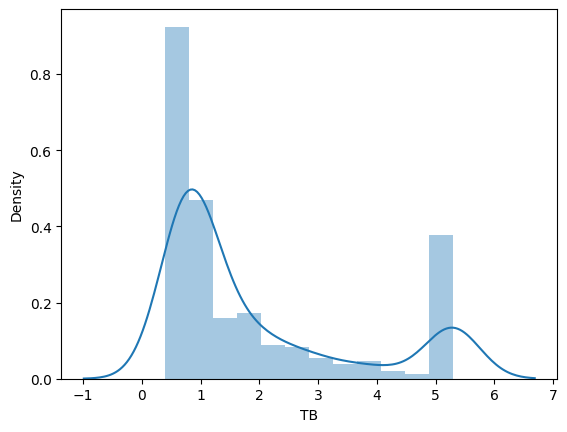

In [32]:
sns.distplot(df['TB'])

In [33]:
def pdf_proba(dataset,startrange,endrange):
    from scipy.stats import norm
    import matplotlib.pyplot as plt
    ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    plt.axvline(startrange,color='Red')
    plt.axvline(endrange,color='Red')
    sample=dataset
    sample_mean=sample.mean()
    sample_std=sample.std()
    print('Mean={:.3f},Satandard Deviation={:.3f}'.format(sample_mean,sample_std))
    dist=norm(sample_mean,sample_std)
    values=[value for value in range(startrange,endrange)]
    probabilities=[dist.pdf(values) for value in values]
    prob=sum(probabilities)
    print("The area range between({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob

Mean=1.921,Satandard Deviation=1.654
The area range between(0,1):[0.12284239]


C:\Users\Sathish\AppData\Local\Temp\ipykernel_11600\2349407750.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


array([0.12284239])

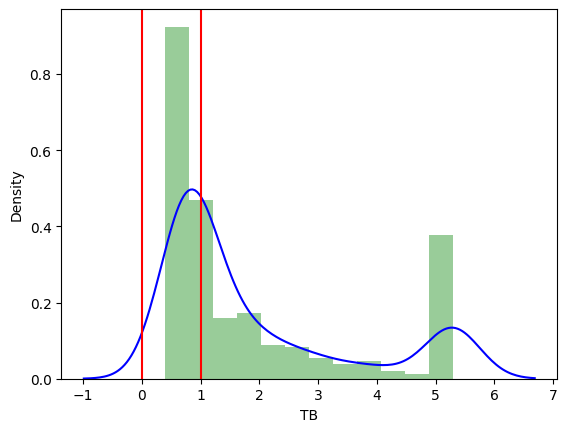

In [34]:
pdf_proba(dataset['TB'],0,1)

Mean=251.259,Satandard Deviation=109.474
The area range between(100,120):[0.02805975 0.02841495 0.02877225 0.02913161 0.029493   0.02985638
 0.03022172 0.03058897 0.0309581  0.03132908 0.03170185 0.03207638
 0.03245263 0.03283056 0.03321011 0.03359125 0.03397393 0.0343581
 0.03474371 0.03513072]


C:\Users\Sathish\AppData\Local\Temp\ipykernel_11600\2349407750.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


array([0.02805975, 0.02841495, 0.02877225, 0.02913161, 0.029493  ,
       0.02985638, 0.03022172, 0.03058897, 0.0309581 , 0.03132908,
       0.03170185, 0.03207638, 0.03245263, 0.03283056, 0.03321011,
       0.03359125, 0.03397393, 0.0343581 , 0.03474371, 0.03513072])

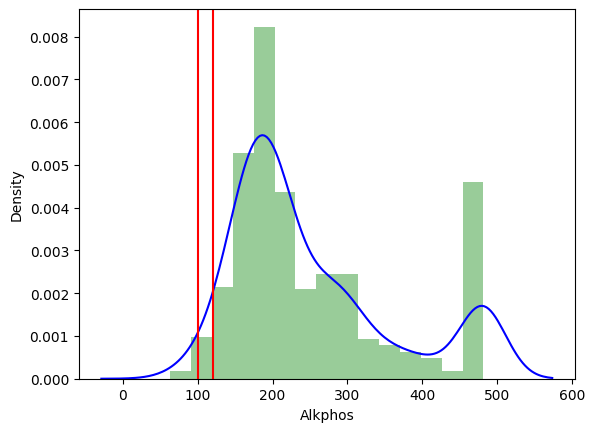

In [38]:
pdf_proba(dataset['Alkphos'],100,120)

In [ ]:
# The line represent the probability's density between Alkphos 100 and 120.

In [44]:
# Standard Normal distribution

def stdgraph(dataset):
    import seaborn as sns
    mean=dataset.mean()
    std=dataset.std()
    values=[i for i in dataset]
    z_score=[((j-mean)/std) for j in values]
    sns=sns.distplot(z_score,kde=True)
    sum(z_score)/len(z_score)
    return dataset

C:\Users\Sathish\AppData\Local\Temp\ipykernel_11600\183585114.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns=sns.distplot(z_score,kde=True)


0      0.7
1      5.3
2      5.3
3      1.0
4      3.9
      ... 
578    0.5
579    0.6
580    0.8
581    1.3
582    1.0
Name: TB, Length: 583, dtype: float64

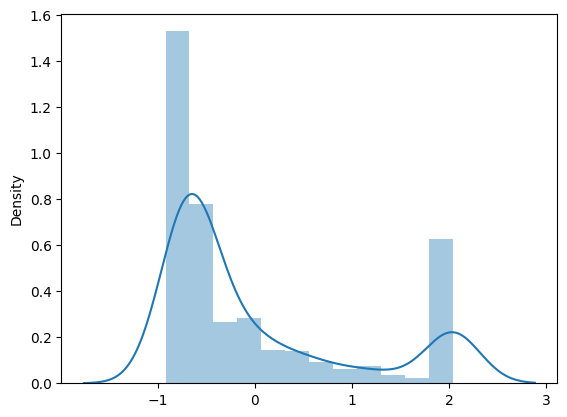

In [45]:
stdgraph(dataset['TB'])

In [ ]:
# The standard normal distribution of TB's density normal is high

C:\Users\Sathish\AppData\Local\Temp\ipykernel_11600\183585114.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns=sns.distplot(z_score,kde=True)


0      65
1      62
2      62
3      58
4      72
       ..
578    60
579    40
580    52
581    31
582    38
Name: Age, Length: 583, dtype: int64

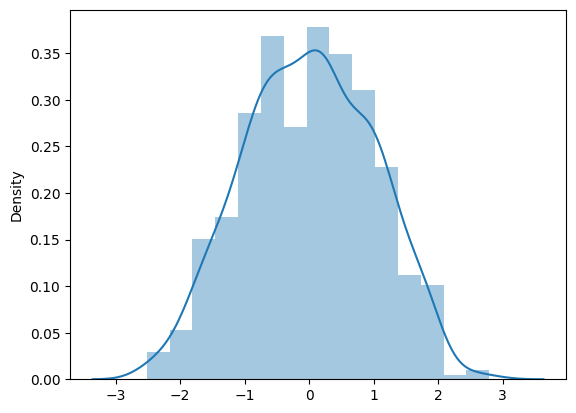

In [46]:
stdgraph(dataset['Age'])

In [47]:
# In Standard normal distribution, always normal is high when compared high and low.

C:\Users\Sathish\AppData\Local\Temp\ipykernel_11600\183585114.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns=sns.distplot(z_score,kde=True)


0      0.10
1      2.95
2      2.95
3      0.40
4      2.00
       ... 
578    0.10
579    0.10
580    0.20
581    0.50
582    0.30
Name: DB, Length: 583, dtype: float64

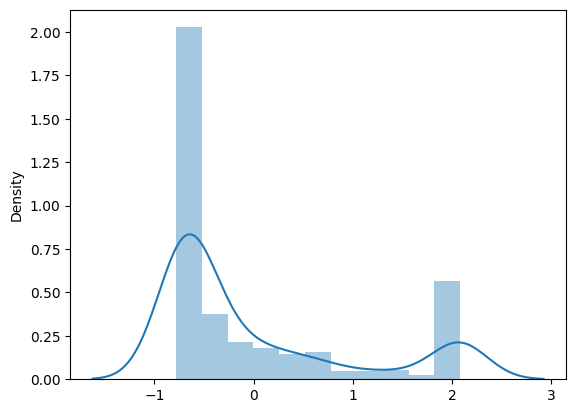

In [48]:
stdgraph(dataset['DB'])

C:\Users\Sathish\AppData\Local\Temp\ipykernel_11600\183585114.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns=sns.distplot(z_score,kde=True)


0      187.00
1      481.75
2      481.75
3      182.00
4      195.00
        ...  
578    481.75
579     98.00
580    245.00
581    184.00
582    216.00
Name: Alkphos, Length: 583, dtype: float64

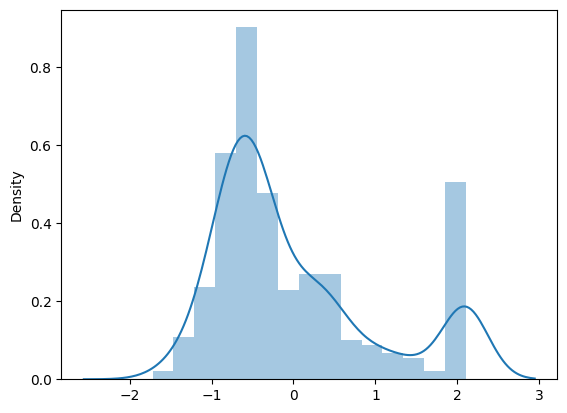

In [49]:
stdgraph(dataset['Alkphos'])

C:\Users\Sathish\AppData\Local\Temp\ipykernel_11600\183585114.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns=sns.distplot(z_score,kde=True)


0      16.0
1      64.0
2      60.0
3      14.0
4      27.0
       ... 
578    20.0
579    35.0
580    48.0
581    29.0
582    21.0
Name: Sgpt, Length: 583, dtype: float64

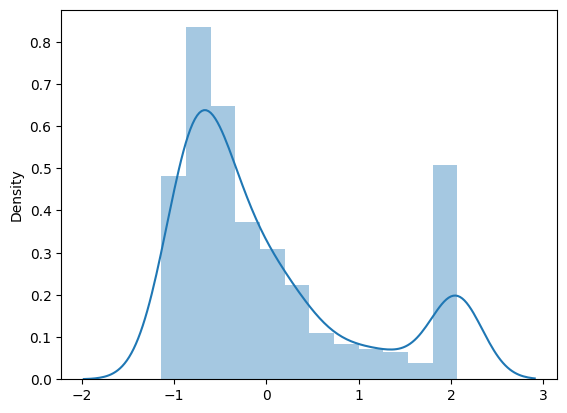

In [50]:
stdgraph(dataset['Sgpt'])

In [ ]:
#The sgbt is a liver enzyme. if it is high, the liver cell damage.
#The std normal distribution of 'sgbt' normal density is high. less high value and no poor value.

C:\Users\Sathish\AppData\Local\Temp\ipykernel_11600\183585114.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns=sns.distplot(z_score,kde=True)


0       18
1      100
2       68
3       20
4       59
      ... 
578     34
579     31
580     49
581     32
582     24
Name: Sgot, Length: 583, dtype: int64

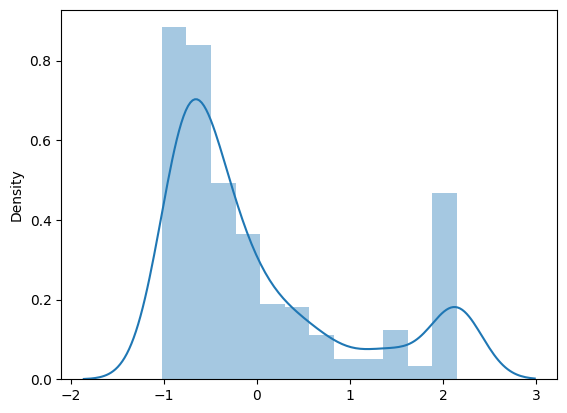

In [52]:
stdgraph(dataset['Sgot'])

In [ ]:
#The sgot is a liver enzyme. if it is high, the liver cell damage.
#The std normal distribution of 'sgbt' normal density is high. less high value and no poor value.

C:\Users\Sathish\AppData\Local\Temp\ipykernel_11600\183585114.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns=sns.distplot(z_score,kde=True)


0      6.8
1      7.5
2      7.0
3      6.8
4      7.3
      ... 
578    5.9
579    6.0
580    6.4
581    6.8
582    7.3
Name: TP, Length: 583, dtype: float64

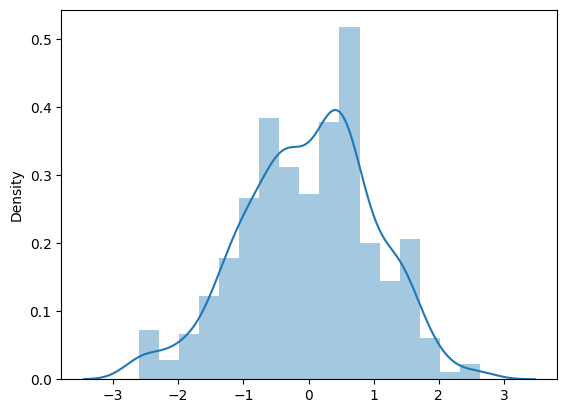

In [53]:
stdgraph(dataset['TP'])

In [ ]:
#'TP' is total protein, if it low causes liver and kidney issues.

C:\Users\Sathish\AppData\Local\Temp\ipykernel_11600\183585114.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns=sns.distplot(z_score,kde=True)


0      3.3
1      3.2
2      3.3
3      3.4
4      2.4
      ... 
578    1.6
579    3.2
580    3.2
581    3.4
582    4.4
Name: ALB, Length: 583, dtype: float64

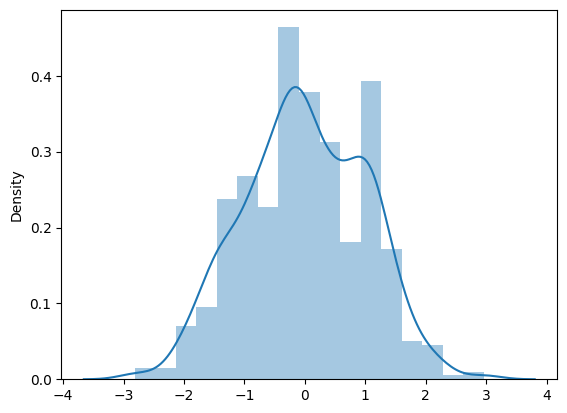

In [54]:
stdgraph(dataset['ALB'])

In [ ]:
# The ALB is Albumin. if it is low,poor liver function.

C:\Users\Sathish\AppData\Local\Temp\ipykernel_11600\183585114.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns=sns.distplot(z_score,kde=True)


0      0.90
1      0.74
2      0.89
3      1.00
4      0.40
       ... 
578    0.37
579    1.10
580    1.00
581    1.00
582    1.50
Name: A/G Ratio, Length: 583, dtype: float64

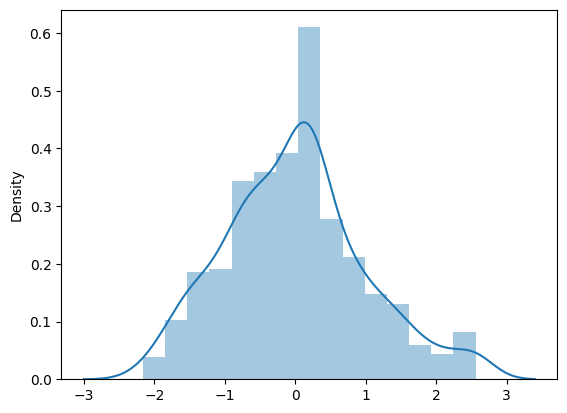

In [55]:
stdgraph(dataset['A/G Ratio'])

C:\Users\Sathish\AppData\Local\Temp\ipykernel_11600\183585114.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns=sns.distplot(z_score,kde=True)


0      1
1      1
2      1
3      1
4      1
      ..
578    0
579    1
580    1
581    1
582    0
Name: Selector, Length: 583, dtype: int64

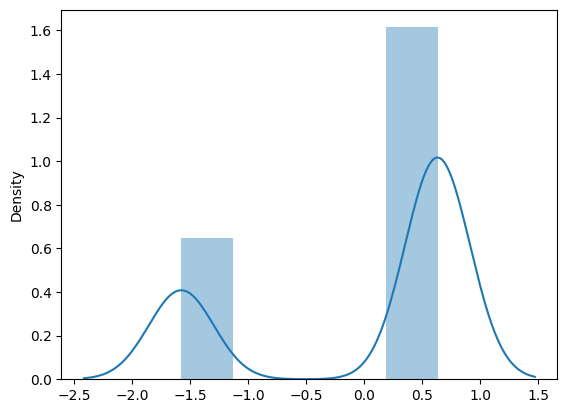

In [56]:
stdgraph(dataset['Selector'])